# Report Visualizations and Tables.
This may look a little weird, but it was the nicest way I could think of to display all of the data needed for the final report in one place. 

In [1]:
# First lets look at our model stats
import pickle
with open("Data/model_stats.pickle", "rb") as f:
    model_stats = pickle.load(f)

for key in model_stats:
    print(key)
    for stat in model_stats[key]:
        if ("f1" in stat or "recall" in stat or "precision" in stat or "brier" in stat) and ("curve" not in stat):
            print(stat, model_stats[key][stat])

RandomForest
brier_skill_score 0.42096768148951635
success_f1 0.9498525073746312
success_precision 0.9235181644359465
success_recall 0.9777327935222672
failure_f1 0.5486725663716814
failure_precision 0.7380952380952381
failure_recall 0.43661971830985913
LogisticRegression4Comp
brier_skill_score 0.2950495265516411
success_f1 0.935672514619883
success_precision 0.9022556390977443
success_recall 0.97165991902834
failure_f1 0.36538461538461536
failure_precision 0.5757575757575758
failure_recall 0.2676056338028169
LogisticRegressionDirection
brier_skill_score 0.29959080671103566
success_f1 0.9387755102040817
success_precision 0.902803738317757
success_recall 0.9777327935222672
failure_f1 0.37623762376237624
failure_precision 0.6333333333333333
failure_recall 0.2676056338028169
SVM
brier_skill_score 0.2959237073508558
success_f1 0.9430255402750491
success_precision 0.916030534351145
success_recall 0.97165991902834
failure_f1 0.48214285714285715
failure_precision 0.6585365853658537
failure_re

RandomForest
[('wave_height', np.float64(0.178651953726155)), ('u_wind', np.float64(0.08675996827885801)), ('v_wind', np.float64(0.15923547015443315)), ('wind_magnitude', np.float64(0.12659370889766047)), ('wave_period', np.float64(0.06969612856479966)), ('precipitation', np.float64(0.07334448456725425)), ('day_sin', np.float64(0.0744206075858748)), ('day_cos', np.float64(0.08607309588140352)), ('wave_direction_sin', np.float64(0.06767146057530843)), ('wave_direction_cos', np.float64(0.0775531217682527))]


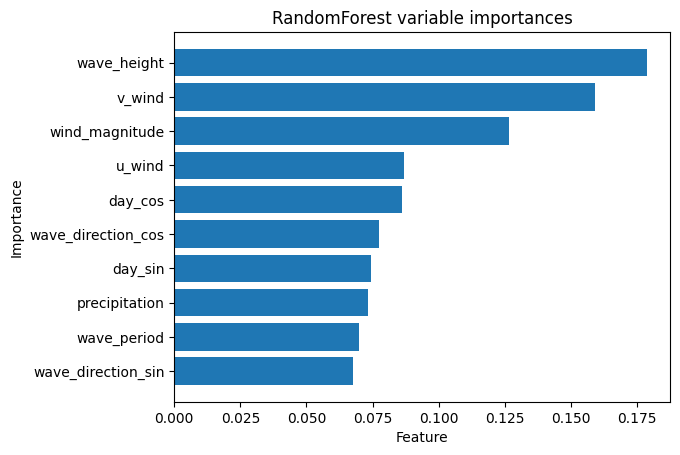

XGBoost
[(np.str_('wave_height'), np.float32(0.18884113)), (np.str_('u_wind'), np.float32(0.06980131)), (np.str_('v_wind'), np.float32(0.19776005)), (np.str_('wind_magnitude'), np.float32(0.111127555)), (np.str_('wave_period'), np.float32(0.06679241)), (np.str_('precipitation'), np.float32(0.07718142)), (np.str_('day_sin'), np.float32(0.06708987)), (np.str_('day_cos'), np.float32(0.07761513)), (np.str_('wave_direction_sin'), np.float32(0.07575353)), (np.str_('wave_direction_cos'), np.float32(0.06803751))]


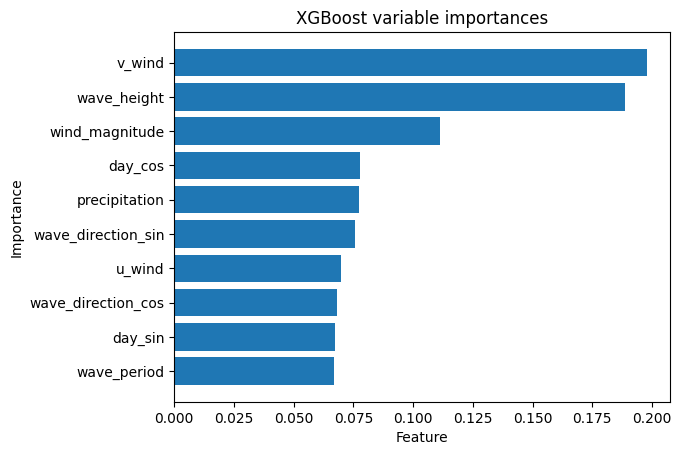

In [2]:
import matplotlib.pyplot as plt
# What are the feature importances?
for key in model_stats:
    if "importances" in model_stats[key]:
        print(key)
        print(model_stats[key]["importances"])

        plt.title(f"{key} variable importances")
        
        importances = model_stats[key]["importances"].copy()
        importances.sort(key=lambda x: x[1])
        
        plt.barh([x[0] for x in importances], [x[1] for x in importances])
        plt.xlabel("Feature")
        plt.ylabel("Importance")
        plt.show()

In [3]:
import make_results_table
make_results_table.generate_table(model_stats, "Data/results_table.docx")
print(model_stats)

Saved to Data/results_table.docx
{'RandomForest': {'brier_skill_score': 0.42096768148951635, 'success_f1': 0.9498525073746312, 'success_precision': 0.9235181644359465, 'success_recall': 0.9777327935222672, 'success_roc_curve': (array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.01408451, 0.01408451, 0.01408451,
       0.04225352, 0.04225352, 0.04225352, 0.04225352, 0.04225352,
       0.04225352, 0.04225352, 0.04225352, 0.04225352, 0.04225352,
       0.04225352, 0.04225352, 0.04225352, 0.04225352, 0.04225352,
       0.04225352, 0.04225352, 0.04225352, 0.04225352, 0.04225352,
       0.04225352, 0.04225352, 0.04225352, 0.04225352, 0.04225352,
       0.04225352, 0.04225352, 0.04225352, 0.04225352, 0.04225352,
       0.04225352, 0.04225352, 0.04225352, 0.05633803, 0.05633803,
       0.05633803, 0.05633803, 0.05633803, 0.05633803, 0.07042254,
       0.07042254, 0.07042254, 0.07

In [4]:
# How much of the data consists of failures?
import pandas as pd
with open("Data/combined_visits_with_weather.csv", "r") as f:
    df = pd.read_csv(f)
print(df["was_successful"].value_counts())

was_successful
True     1978
False     282
Name: count, dtype: int64


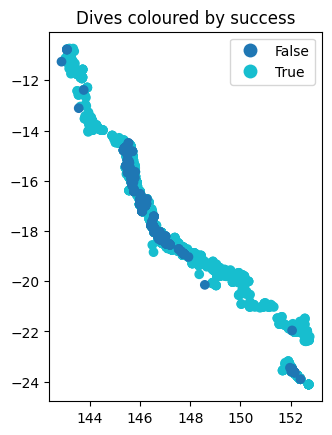

In [5]:
# Let's plot the dives in geopandas. Coloured by success.
import geopandas as gpd
from shapely.geometry import Point

# Dive Points
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["x"], df["y"]))
gdf.plot(column="was_successful", legend=True)
plt.title("Dives coloured by success")
plt.show()